# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
# Inspect the shapes of the datasets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


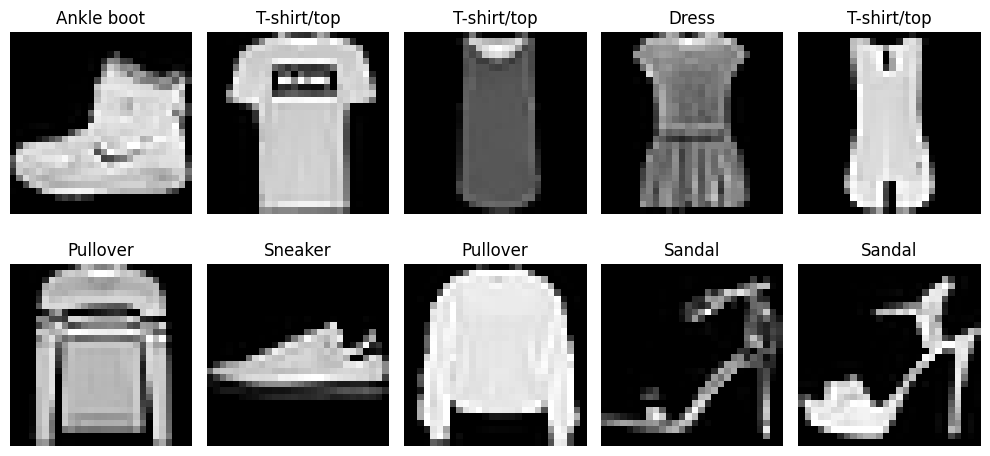

In [3]:
import matplotlib.pyplot as plt
# Verify the data looks as expected
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i].argmax()])
    plt.axis('off')
plt.tight_layout()
plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

Yes, the data looks as expected.

- Images are 28×28 grayscale and centered.
- Labels match the clothing items shown.
- Quality is low-resolution and slightly pixelated.

No obvious issues. The only limitation is low resolution and some visually similar classes, which can make classification harder.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [4]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()

# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(10))

# Compile the model using `model.compile()`
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with `model.fit()`
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model with `model.evaluate()`
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

c:\Users\kamoornani\Assignments\deep_learning\deep-learning-env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.1799 - loss: 11.0002 - val_accuracy: 0.1478 - val_loss: 12.2540
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1492 - loss: 13.0094 - val_accuracy: 0.1507 - val_loss: 12.8490
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1481 - loss: 13.0073 - val_accuracy: 0.1482 - val_loss: 12.5667
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1610 - loss: 12.2477 - val_accuracy: 0.1608 - val_loss: 12.1048
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1519 - loss: 12.2925 - val_accuracy: 0.1133 - val_loss: 11.2989
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1369 - loss: 12.3764 - val_accuracy: 0.1278 - val_loss: 12.6098
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1500 - loss: 12.4712 - val_accuracy: 0.1573 - val_loss: 12.4782
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1636 - l

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

Baseline Performance:
- Test accuracy = 17.7%
- Test loss = 12.78

This is only slightly better than random guessing (10% for 10 classes), and much worse than expected for a linear softmax classifier.

Reason:

The output layer has no softmax activation, but categorical_crossentropy expects probabilities. This mismatch prevents proper learning, leading to very poor performance.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [5]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Epoch 1/10


c:\Users\kamoornani\Assignments\deep_learning\deep-learning-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 64s 38ms/step - accuracy: 0.8624 - loss: 0.3802 - val_accuracy: 0.8905 - val_loss: 0.3060
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 60s 36ms/step - accuracy: 0.9087 - loss: 0.2463 - val_accuracy: 0.9035 - val_loss: 0.2663
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 59s 35ms/step - accuracy: 0.9290 - loss: 0.1897 - val_accuracy: 0.9003 - val_loss: 0.2774
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 57s 34ms/step - accuracy: 0.9457 - loss: 0.1485 - val_accuracy: 0.9075 - val_loss: 0.2801
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 57s 34ms/step - accuracy: 0.9582 - loss: 0.1139 - val_accuracy: 0.9077 - val_loss: 0.3056
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 58s 34ms/step - accuracy: 0.9685 - loss: 0.0857 - val_accuracy: 0.9025 - val_loss: 0.3541
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9765 - loss: 0.0652 - val_accuracy: 0.9078 - val_loss: 0.3727
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9823 - loss: 0.05

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

Yes, the CNN performed much better.
- Baseline accuracy: 17.7%
- CNN accuracy: 90.2%
- Improvement: 72.5%

The improvement comes from convolutional layers learning spatial features (edges, shapes) and preserving the 2D structure of images, unlike the linear model.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

Hyperparameter experiments (number of filters):
 filters dropout  test_loss  test_accuracy
      16      No   0.309883         0.9005
      32      No   0.309660         0.9008
      64      No   0.338779         0.8970


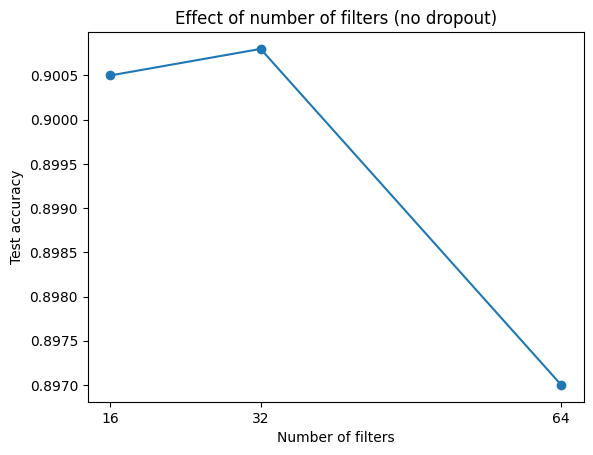

In [ ]:
# A. Test Hyperparameters
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense, Dropout

filters_list = [16, 32, 64] # hyperparameter: number of filters (at least 3 values)
epochs = 5
batch_size = 32

hp_results = []

for n_filters in filters_list:
    # Re-initialize model each run
    model = Sequential()
    model.add(Conv2D(n_filters, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0)

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    hp_results.append({
        "filters": n_filters,
        "dropout": "No",
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
    })

hp_df = pd.DataFrame(hp_results).sort_values("filters")
print("Hyperparameter experiments (number of filters):")
print(hp_df.to_string(index=False))

plt.figure()
plt.plot(hp_df["filters"], hp_df["test_accuracy"], marker='o')
plt.xlabel("Number of filters")
plt.ylabel("Test accuracy")
plt.title("Effect of number of filters (no dropout)")
plt.xticks(hp_df["filters"])
plt.show()

c:\Users\kamoornani\Assignments\deep_learning\deep-learning-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Regularization experiments (dropout on/off):
 filters dropout  test_loss  test_accuracy
      32      No   0.301221         0.9063
      32     Yes   0.273472         0.9022


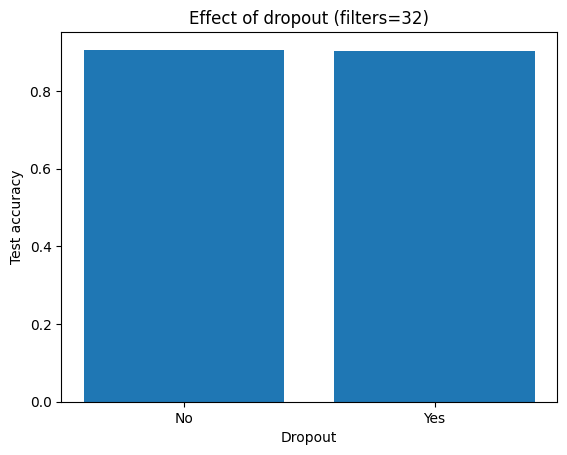

In [ ]:
# B. Test presence or absence of regularization
base_filters = 32
dropout_settings = [False, True]
reg_results = []

for use_dropout in dropout_settings:
    # Re-initialize model each run
    model = Sequential()
    model.add(Conv2D(base_filters, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    if use_dropout:
        model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0)

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    reg_results.append({
        "filters": base_filters,
        "dropout": "Yes" if use_dropout else "No",
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
    })

reg_df = pd.DataFrame(reg_results)
print("\nRegularization experiments (dropout on/off):")
print(reg_df.to_string(index=False))

plt.figure()
plt.bar(reg_df["dropout"], reg_df["test_accuracy"])
plt.xlabel("Dropout")
plt.ylabel("Test accuracy")
plt.title(f"Effect of dropout (filters={base_filters})")
plt.show()

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

1. Hyperparameter: Number of Filters (no dropout)
- 16 filters -> Test Accuracy = 90.05%
- 32 filters -> Test Accuracy = 90.08%
- 64 filters -> Test Accuracy = 89.70%

    In this regard:
- Increasing filters from 16 to 32 slightly improved performance.
- Increasing to 64 filters decreased performance due to mild overfitting or insufficient training epochs.
- Best (no dropout): 32 filters (90.08%)
2. Regularization: Dropout (filters = 32)
- Dropout slightly reduced accuracy.
- However, dropout lowered test loss, indicating slightly better regularization.

    Best (regularization test): 32 filters, no dropout (90.63%)
3. Did any changes improve performance?

    Yes:
- Increasing filters from 16 to 32 improved performance slightly.
- Dropout did not improve accuracy but improved loss stability.
4. Best Combination: 32 filters + no dropout (Test accuracy = 90.63%)

    This combination yielded the highest test accuracy among the tested models.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [8]:
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense

# Build the final model using the best setting found: 32 filters, no dropout
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compile the final model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the final model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the final model
test_loss, test_acc = model.evaluate(X_test, y_test)

# Report final performance
print("Final Test loss:", test_loss)
print("Final Test accuracy:", test_acc)

c:\Users\kamoornani\Assignments\deep_learning\deep-learning-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - accuracy: 0.8635 - loss: 0.3809 - val_accuracy: 0.8915 - val_loss: 0.2969
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.9090 - loss: 0.2483 - val_accuracy: 0.8977 - val_loss: 0.2757
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.9290 - loss: 0.1894 - val_accuracy: 0.9087 - val_loss: 0.2635
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 77s 34ms/step - accuracy: 0.9459 - loss: 0.1442 - val_accuracy: 0.9050 - val_loss: 0.2966
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 57s 34ms/step - accuracy: 0.9592 - loss: 0.1098 - val_accuracy: 0.9068 - val_loss: 0.3025
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 85s 36ms/step - accuracy: 0.9687 - loss: 0.0849 - val_accuracy: 0.9057 - val_loss: 0.3309
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 59s 35ms/step - accuracy: 0.9772 - loss: 0.0645 - val_accuracy: 0.9025 - val_loss: 0.3804
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 57s 34ms/step - accuracy: 0.9834 -

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

Performance Comparison:
- Baseline: 17.7%
- CNN: 90.2%
- Final model: 90.3%

The final model greatly outperforms the baseline and performs similarly to the CNN.

What contributed to the final performance?
- Convolutional layers learn hierarchical representations.
- Proper cross-entropy training with backprop enables effective optimization.
- Model capacity must balance bias and variance.

The train-test gap indicates mild overfitting.

Further experiments:
- Adjust model width/depth.
- Add L2 regularization. 
- Tune dropout.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.